In [2]:
import ee 
from RadGEEToolbox import GenericCollection, LandsatCollection, get_palette
# import GEE_UBM
from GEE_UBM import InputCollections, build_model_ready_collection, OriginalUBMRun, ModifiedUBM1Run, check_merged_collection
import geemap
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import pandas as pd

In [3]:
service_account = 'localpythonscripts@ut-gee-ugs-bsf-dev.iam.gserviceaccount.com'
credentials = ee.ServiceAccountCredentials(service_account, 'C:\\Users\\mradwin\\ut-gee-ugs-bsf-dev-53dcc5d729e0.json')
ee.Initialize(credentials=credentials)

# try:
#     ee.Initialize()
# except Exception as e:
#     ee.Authenticate()
#     ee.Initialize()

In [4]:
UT_boundary = ee.FeatureCollection("projects/ut-gee-ugs-bsf-dev/assets/Utah_Regional_Boundary").geometry()

#### Update `zonal_stats_df = pd.read_csv()` with the path of the data you are looking to plot

In [7]:
zonal_stats_df = pd.read_csv('C:\\Users\\mradwin\\Documents\\Utah Soil Water Balance\\Zonal_Stats_Timeseries\\GSL_Basin\\Modified_UBM_1_UT_RF1kmST_POLARISPor_OLMFC_HHSWP_POLARISKsatM_DAYMETSNODASM_OPENETEEMETRIC_M_m3_Zonal_Stats_GSL_Basin_Watershed.csv')
zonal_stats_df['Date'] = pd.to_datetime(zonal_stats_df['Date'])
print(zonal_stats_df.head())

        Date   Recharge_m3     Runoff_m3  Soil_Water_End_m3        AET_m3  \
0 2005-01-01  2.183344e+09  7.156984e+07       6.876768e+09  1.412487e+08   
1 2005-02-01  1.620064e+09  1.629534e+07       7.054341e+09  2.330679e+08   
2 2005-03-01  1.225722e+09  7.792767e+07       6.914374e+09  9.671611e+08   
3 2005-04-01  1.277503e+09  7.883005e+06       6.981708e+09  8.939310e+08   
4 2005-05-01  1.812796e+09  8.334571e+06       7.092669e+09  1.207228e+09   

   Precip_and_Snowmelt_m3  
0            3.154911e+09  
1            2.228019e+09  
2            2.100324e+09  
3            2.344009e+09  
4            3.428560e+09  


#### Comment out lines not included in the dataset you are looking to plot (AET and Precip_and_Snowmelt may not be included in the dataset)

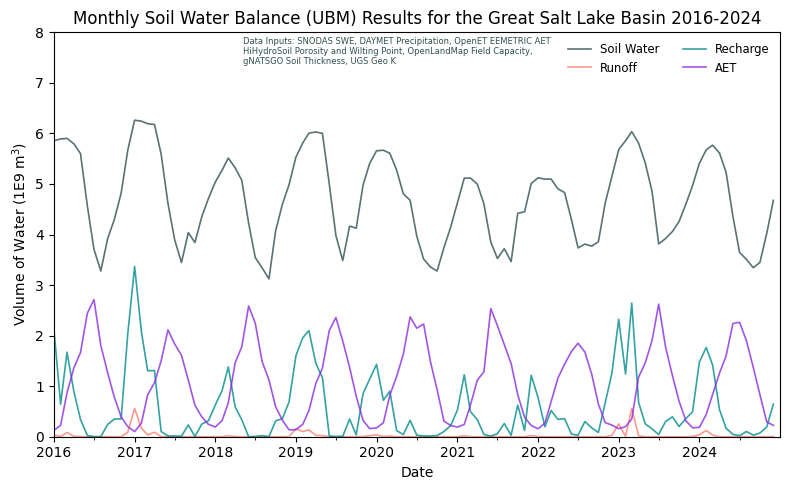

In [9]:
markersize = 0
alpha = 0.8
linewidth = 1.2
plt.figure(figsize=(8,5))
plt.plot(zonal_stats_df['Date'], zonal_stats_df['Soil_Water_End_m3'], marker='o', color='darkslategrey', markersize=markersize, linewidth=linewidth, alpha=alpha, label='Soil Water')
plt.plot(zonal_stats_df['Date'], zonal_stats_df['Runoff_m3'], marker='o', color='salmon', markersize=markersize, linewidth=linewidth, alpha=alpha, label='Runoff')
plt.plot(zonal_stats_df['Date'], zonal_stats_df['Recharge_m3'], marker='o', color='darkcyan', markersize=markersize, linewidth=linewidth, alpha=alpha, label='Recharge') #darkorchid
plt.plot(zonal_stats_df['Date'], zonal_stats_df['AET_m3'], marker='o', color='blueviolet', markersize=markersize, linewidth=linewidth, alpha=alpha, label='AET')
# plt.plot(zonal_stats_df['Date'], zonal_stats_df['Precip_and_Snowmelt_m3'], marker='o', color='deepskyblue', markersize=markersize, linewidth=linewidth, alpha=alpha, label='Precipitation and Snowmelt')
plt.xlim(pd.Timestamp('2016-01-01'), pd.Timestamp('2024-12-31'))
plt.gca().xaxis.set_minor_locator(mdates.MonthLocator(7))
plt.gca().yaxis.get_offset_text().set_visible(False)
plt.ylim(0, 8E9)
plt.title('Monthly Soil Water Balance (UBM) Results for the Great Salt Lake Basin 2016-2024')
plt.xlabel('Date')
plt.ylabel('Volume of Water (1E9 m$^3$)')
plt.legend(loc='upper right', fontsize='small', frameon=False, ncol=2)
plt.annotate('Data Inputs: SNODAS SWE, DAYMET Precipitation, OpenET EEMETRIC AET\nHiHydroSoil Porosity and Wilting Point, OpenLandMap Field Capacity,\ngNATSGO Soil Thickness, UGS Geo K', xy=(0,0), xycoords='figure fraction', xytext=(175,305), textcoords='offset points', ha='left', va='bottom', fontsize=6, color='darkslategray')
plt.tight_layout()
# plt.savefig('C:\\Users\\mradwin\\Documents\\Utah Soil Water Balance\\Figures\\Aggregated_Modified1_UBM_UT_HSPor_OLMFC_HSWP_UGSGK_DAYMETSNODAS_OPENET_M\\GSL_Basin_UBM_M1_Soil_Water_Balance_2016_2024.png', dpi=600)
plt.show()

In [11]:
terra_stats = pd.read_csv('C:\\Users\\mradwin\\Documents\\Utah Soil Water Balance\\Zonal_Stats_Timeseries\\GSL_Basin\\GSL_Basin_Terraclimate_Stats_2016_2024.csv')
terra_stats['Date'] = pd.to_datetime(terra_stats['Date'])
print(terra_stats.head())

        Date  Terraclimate_Runoff_m3  Terraclimate_Soil_Water_m3  \
0 2016-01-01            6.988666e+05                2.810389e+09   
1 2016-02-01            7.796147e+07                1.126457e+10   
2 2016-03-01            3.335450e+08                1.696870e+10   
3 2016-04-01            2.517797e+08                1.378843e+10   
4 2016-05-01            6.626176e+07                9.192754e+09   

   Terraclimate_AET_m3  
0         4.305611e+07  
1         5.515243e+09  
2         1.972623e+10  
3         1.794966e+10  
4         1.502069e+10  


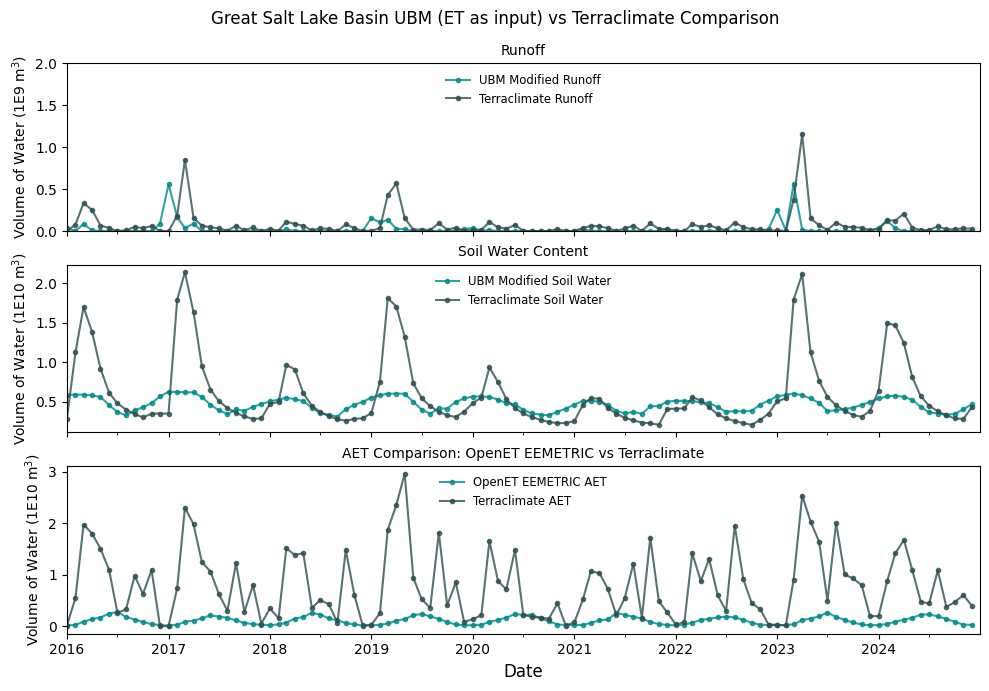

In [12]:
fig, ax = plt.subplots(figsize=(10,7), nrows=3, sharex=True)
markersize = 3
plt.suptitle('Great Salt Lake Basin UBM (ET as input) vs Terraclimate Comparison')
ax[0].plot(zonal_stats_df['Date'], zonal_stats_df['Runoff_m3'], marker='o', color='darkcyan', markersize=markersize, alpha=alpha, label='UBM Modified Runoff')
ax[0].plot(terra_stats['Date'], terra_stats['Terraclimate_Runoff_m3'], marker='o', color='darkslategrey', markersize=markersize, alpha=alpha, label='Terraclimate Runoff')
ax[0].legend(loc='upper center', fontsize='small', frameon=False)
ax[0].set_title('Runoff', fontsize=10)
# ax[0].set_ylim(0, 1.25E9)
ax[0].set_ylim(0, 2E9)
ax[0].set_xlim(pd.Timestamp('2016-01-01'), pd.Timestamp('2024-12-31'))
ax[0].xaxis.set_minor_locator(mdates.MonthLocator(7))
ax[0].yaxis.get_offset_text().set_visible(False)
ax[0].set_ylabel('Volume of Water (1E9 m$^3$)')
# ax[0].plot(zonal_stats_df['Runoff_m3'], terra_stats['Terraclimate_Runoff_m3'], marker='o', color='deepskyblue', markersize=markersize, linewidth=0, alpha=alpha)

ax[1].plot(zonal_stats_df['Date'], zonal_stats_df['Soil_Water_End_m3'], marker='o', color='darkcyan', markersize=markersize, alpha=alpha, label='UBM Modified Soil Water')
ax[1].plot(terra_stats['Date'], terra_stats['Terraclimate_Soil_Water_m3'], marker='o', color='darkslategrey', markersize=markersize, alpha=alpha, label='Terraclimate Soil Water')
ax[1].set_title('Soil Water Content', fontsize=10)
ax[1].legend(loc='upper center', fontsize='small', frameon=False)
ax[1].yaxis.get_offset_text().set_visible(False)
ax[1].set_ylabel('Volume of Water (1E10 m$^3$)')

ax[2].plot(zonal_stats_df['Date'], zonal_stats_df['AET_m3'], marker='o', color='darkcyan', markersize=markersize, alpha=alpha, label='OpenET EEMETRIC AET')
ax[2].plot(terra_stats['Date'], terra_stats['Terraclimate_AET_m3'], marker='o', color='darkslategrey', markersize=markersize, alpha=alpha, label='Terraclimate AET')
ax[2].set_title('AET Comparison: OpenET EEMETRIC vs Terraclimate', fontsize=10)
ax[2].legend(loc='upper center', fontsize='small', frameon=False)
ax[2].yaxis.get_offset_text().set_visible(False)
ax[2].set_ylabel('Volume of Water (1E10 m$^3$)')
ax[2].set_xlabel('Date', fontsize=12)

# reduce the vertical space between subplots


plt.tight_layout()
fig.subplots_adjust(hspace=0.2)
# plt.savefig('C:\\Users\\mradwin\\Documents\\Utah Soil Water Balance\\Figures\\Aggregated_Modified1_UBM_UT_HSPor_OLMFC_HSWP_UGSGK_DAYMETSNODAS_OPENET_M\\GSL_Basin_UBM_M1_Soil_Water_Balance_2016_2024_Compared_to_Terraclimate.png', dpi=600)